In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split,KFold, cross_validate, GridSearchCV,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [14]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x: f"{x:3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update ( {
    "axes.titlesize":10,
    "axes.labelsize": 9,
    "xtick.labelsize":8,
    "ytick.labelsize":8,

})
RANDOM_STATE = 42
CSV_PATH ="data.csv"
TARGET_COL = "median_house_value"


In [15]:
df = pd.read_csv(CSV_PATH)
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.000000,3.000000,1.500000,1340,7912,1.500000,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.000000,5.000000,2.500000,3650,9050,2.000000,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.000000,3.000000,2.000000,1930,11947,1.000000,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.000000,3.000000,2.250000,2000,8030,1.000000,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.000000,4.000000,2.500000,1940,10500,1.000000,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [16]:
print("Dataframe shape",df.shape)
print("Dataframe columns",df.columns)

Dataframe shape (4600, 18)
Dataframe columns Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')


column details
1. longitude :A measure of how far west a house is,a higher value is farther west
2. latitude :A measure of how far north a house is, a higher value is farther north
3. houseingmeadianAge:Median age of a house within a block, a lower number is a newer building
4. totalrooms: Total number of rooms within a block
5. totalBedrooms :Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within  a home unit, for a block


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target columns:",TARGET_COL
      )
print("numercal columns",num_cols)
print("categorical columns",cat_cols)

Target columns: median_house_value
numercal columns ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']
categorical columns ['date', 'street', 'city', 'statezip', 'country']


In [19]:
# missing value analysis
print("nMissing value per colum:")
print(df.isna().sum())


nMissing value per colum:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [20]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

date
2014-06-23 00:00:00    142
2014-06-25 00:00:00    131
2014-06-26 00:00:00    131
2014-07-08 00:00:00    127
2014-07-09 00:00:00    121
2014-06-24 00:00:00    120
2014-05-20 00:00:00    116
2014-07-01 00:00:00    116
2014-06-17 00:00:00    113
2014-05-28 00:00:00    111
2014-06-20 00:00:00    107
2014-05-27 00:00:00    104
2014-06-03 00:00:00    104
2014-06-19 00:00:00    101
2014-06-04 00:00:00    100
2014-06-18 00:00:00     99
2014-06-10 00:00:00     98
2014-06-16 00:00:00     97
2014-06-09 00:00:00     95
2014-05-21 00:00:00     94
Name: count, dtype: int64
price
0.000000         49
300000.000000    42
400000.000000    31
440000.000000    29
600000.000000    29
450000.000000    29
350000.000000    28
550000.000000    27
435000.000000    27
415000.000000    27
250000.000000    27
475000.000000    26
530000.000000    26
525000.000000    26
330000.000000    25
425000.000000    24
500000.000000    24
235000.000000    23
385000.000000    23
345000.000000    23
Name: count, dtype: int

In [21]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:",num_duplicates)

Number of duplicate rows: 0


In [22]:
# descriptive stat
df[num_cols].describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,551962.988473,3.400870,2.160815,2139.346957,14852.516087,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,563834.702547,0.908848,0.783781,963.206916,35884.436145,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000,0.000000,0.000000,370.000000,638.000000,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,322875.000000,3.000000,1.750000,1460.000000,5000.750000,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,460943.461539,3.000000,2.250000,1980.000000,7683.000000,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,654962.500000,4.000000,2.500000,2620.000000,11001.250000,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,26590000.000000,9.000000,8.000000,13540.000000,1074218.000000,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


Data visualization


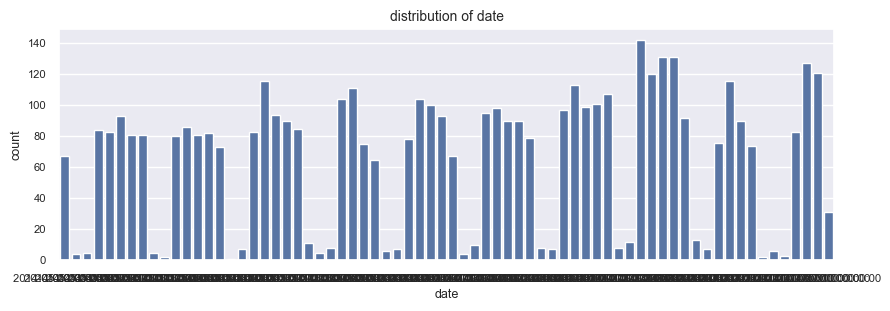

In [ ]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col, data=df)
    plt.title(f"distribution of {col}")
    plt.show()

In [ ]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


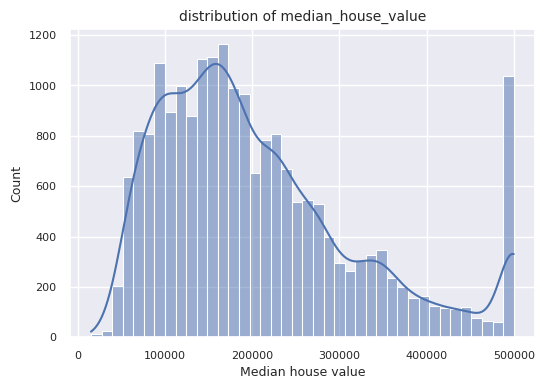

In [ ]:
# target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL],bins=40,kde=True)
plt.title(f"distribution of {TARGET_COL}")
plt.xlabel("Median house value")

plt.show()


In [ ]:
df[TARGET_COL].value_counts()
#higher cap

,count
median_house_value,
500001.000000,965
137500.000000,122
162500.000000,117
112500.000000,103
187500.000000,93
...,...
34200.000000,1
46200.000000,1
352000.000000,1


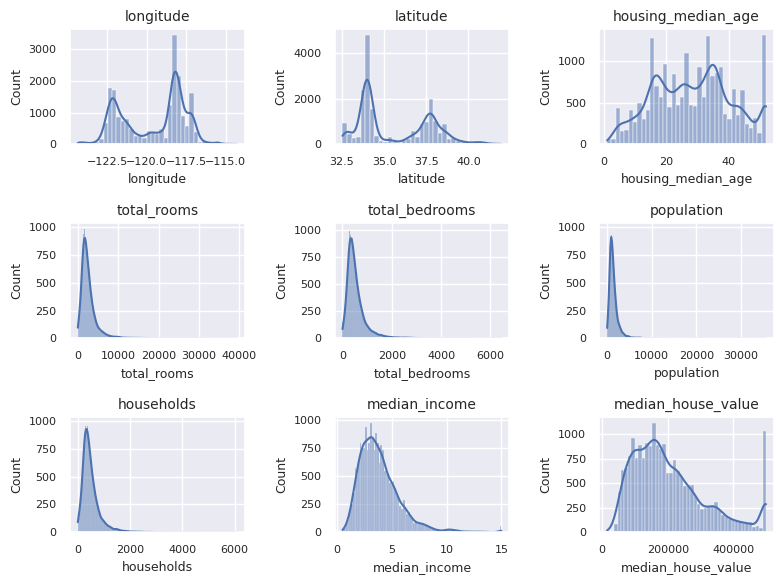

In [ ]:
# histogram plot - distribution
fig, axes = plt.subplots(3,3, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

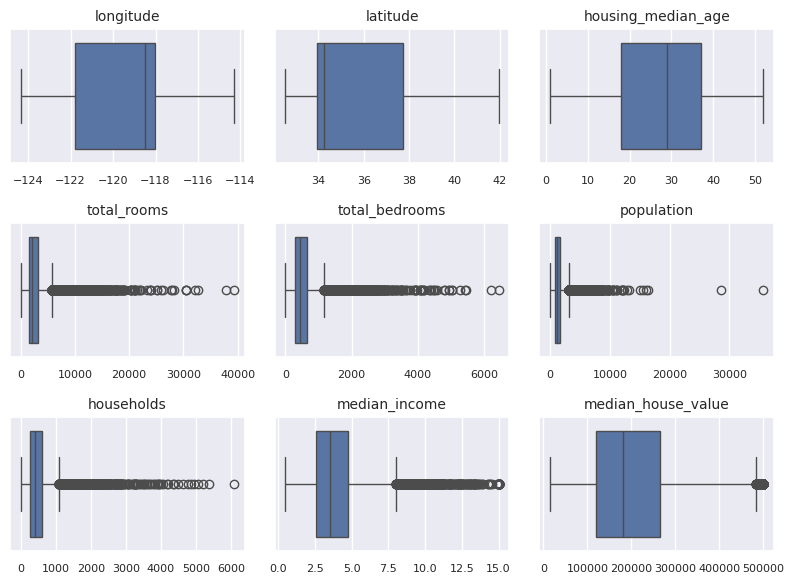

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

In [ ]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3,3,figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

plt.tight_layout



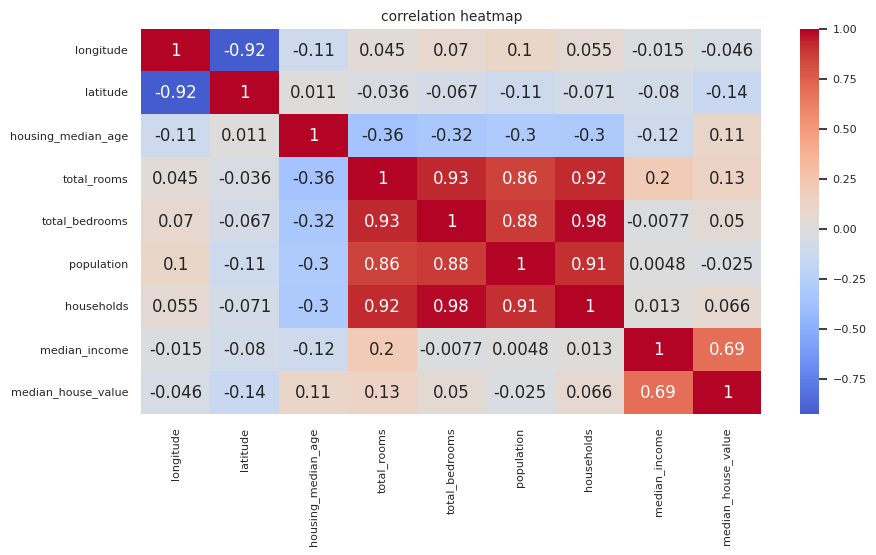

In [ ]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10,5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center = 0
)
plt.title("correlation heatmap")
plt.show()

In [ ]:
# correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)




Correlation with target:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


4. Data preparation

In [ ]:
# separate features and target
x = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [ ]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230000,37.880000,41.000000,880.000000,129.000000,322.000000,126.000000,8.325200,NEAR BAY
1,-122.220000,37.860000,21.000000,7099.000000,1106.000000,2401.000000,1138.000000,8.301400,NEAR BAY
2,-122.240000,37.850000,52.000000,1467.000000,190.000000,496.000000,177.000000,7.257400,NEAR BAY
3,-122.250000,37.850000,52.000000,1274.000000,235.000000,558.000000,219.000000,5.643100,NEAR BAY
4,-122.250000,37.850000,52.000000,1627.000000,280.000000,565.000000,259.000000,3.846200,NEAR BAY


In [ ]:
y.head()

,median_house_value
0,452600.000000
1,358500.000000
2,352100.000000
3,341300.000000
4,342200.000000


In [ ]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [ ]:
print("train shape", x_train.shape)
print("test shape", x_test.shape)

train shape (16512, 9)
test shape (4128, 9)


preprocessing pipeline

In [ ]:
from matplotlib.cbook import simple_linear_interpolation
numerical_features = x_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("numerical_features",numerical_features)
print("categorical_features",categorical_features)

# numerical features - preprocessing steps
numeric_tranformer = Pipeline(steps= [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())

])

# categorical features - preprocessing steps
categorical_tranformer = Pipeline(steps= [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))

])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tranformer, numerical_features),
        ("cat", categorical_tranformer, categorical_features)
    ]
)


numerical_features ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
categorical_features ['ocean_proximity']


In [ ]:
x_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14196,-117.030000,32.710000,33.000000,3126.000000,627.000000,2300.000000,623.000000,3.259600,NEAR OCEAN
8267,-118.160000,33.770000,49.000000,3382.000000,787.000000,1314.000000,756.000000,3.812500,NEAR OCEAN
17445,-120.480000,34.660000,4.000000,1897.000000,331.000000,915.000000,336.000000,4.156300,NEAR OCEAN
14265,-117.110000,32.690000,36.000000,1421.000000,367.000000,1418.000000,355.000000,1.942500,NEAR OCEAN
2271,-119.800000,36.780000,43.000000,2382.000000,431.000000,874.000000,380.000000,3.554200,INLAND
...,...,...,...,...,...,...,...,...,...
11284,-117.960000,33.780000,35.000000,1330.000000,201.000000,658.000000,217.000000,6.370000,<1H OCEAN
11964,-117.430000,34.020000,33.000000,3084.000000,570.000000,1753.000000,449.000000,3.050000,INLAND
5390,-118.380000,34.030000,36.000000,2101.000000,569.000000,1756.000000,527.000000,2.934400,<1H OCEAN
860,-121.960000,37.580000,15.000000,3575.000000,597.000000,1777.000000,559.000000,5.719200,<1H OCEAN


5. Baseline model


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [ ]:
# preprocess the data and train the baseline model
baseline_pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

In [ ]:
train_baseline_pred = baseline_pipe.predict(x_train)
test_baseline_pred = baseline_pipe.predict(x_test)
train_baseline_pred[:5]
y_train[:5]

,median_house_value
14196,103000.000000
8267,382100.000000
17445,172600.000000
14265,93400.000000
2271,96500.000000


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train_baseline_rmse = np.sqrt(mean_squared_error(y_train, train_baseline_pred))
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (Linear Regression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R2: {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (Linear Regression) ===
RMSE: 68433.937
MAE: 49594.842
R2: 0.650


In [ ]:


test_baseline_rmse = np.sqrt(mean_squared_error(y_test, test_baseline_pred))
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (Linear Regression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE: {test_baseline_mae:.3f}")
print(f"R2: {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (Linear Regression) ===
RMSE: 70059.193
MAE: 50670.489
R2: 0.625


6. model selection & optimiztion

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE,max_iter=10000),
    "RandomForestRegressor": RandomForestRegressor(),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor()
}

In [ ]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# Define scoring
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

rows = []

# Loop through models
for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )

    # Cross validation
    scores = cross_validate(
        pipe,
        x_train,   # ✅ correct variable
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # Store results
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),  # convert to positive
        "cv_mae": -scores["test_mae"].mean(),    # convert to positive
        "cv_r2": -scores["test_r2"].mean()        # no minus
    })

# Create dataframe and sort
cv_results = pd.DataFrame(rows).sort_values(by="cv_rmse")

print("==== CV Model Comparison ====")
print(cv_results)

==== CV Model Comparison ====
                           model      cv_rmse       cv_mae     cv_r2
4  HistGradientBoostingRegressor 48226.682856 32308.414448 -0.825963
3          RandomForestRegressor 49484.563250 32258.481568 -0.816782
1                          Ridge 68595.617399 49664.330927 -0.647760
2                          Lasso 68603.233277 49667.262611 -0.647685
0               LinearRegression 68604.162955 49667.159067 -0.647676


In [ ]:
rows

[{'model': 'LinearRegression',
  'cv_rmse': np.float64(68604.16295529754),
  'cv_mae': np.float64(49667.15906724985),
  'cv_r2': np.float64(-0.6476757451183028)},
 {'model': 'Ridge',
  'cv_rmse': np.float64(68595.61739914853),
  'cv_mae': np.float64(49664.330927177056),
  'cv_r2': np.float64(-0.6477600560394983)},
 {'model': 'Lasso',
  'cv_rmse': np.float64(68603.2332772403),
  'cv_mae': np.float64(49667.26261132317),
  'cv_r2': np.float64(-0.6476847875205972)},
 {'model': 'RandomForestRegressor',
  'cv_rmse': np.float64(49484.563249949715),
  'cv_mae': np.float64(32258.481568481053),
  'cv_r2': np.float64(-0.8167816073453629)},
 {'model': 'HistGradientBoostingRegressor',
  'cv_rmse': np.float64(48226.68285639341),
  'cv_mae': np.float64(32308.414447676954),
  'cv_r2': np.float64(-0.8259634992824069)}]

In [ ]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]
best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on cv RMSE:")
print("Model:",best_model_name)
print("cv RMSE",best_rmse)

Best model based on cv RMSE:
Model: HistGradientBoostingRegressor
cv RMSE 48226.68285639341


BEST MODEL : HistGradientBoostingRegressor

In [ ]:
#7. Hyperparameter tuning

In [ ]:
hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))

    ]
)

In [ ]:
# hyperparameter combination
param_grid = {
    "model__learning_rate": [0.03, 0.05, 1.0],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 1.0, 1.0]
}


In [ ]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring = "neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)


In [ ]:
# perform grid search
grid.fit(x_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income'...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 1.0, 1.0],
                         'model__learning_rate': [0.03, 0.05, 1.0],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [ ]:
print("\n=== TUNED HistGB (cv)===")
print("Best CV RMSE",-grid.best_score_)
print("Bset params", grid.best_params_)


=== TUNED HistGB (cv)===
Best CV RMSE 48467.54080495553
Bset params {'model__l2_regularization': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


8. retraining with best parameters


In [ ]:
hgb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            l2_regularization=0.1,
            learning_rate=0.1,
            max_depth=None,
            max_leaf_nodes=63,
            min_samples_leaf=20
        ))
    ]
)

In [ ]:
hgb_best.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63))])

9. final evaluation


In [ ]:
train_final_pred = hgb_best.predict(x_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL(Tuned HGB) train performance ===")
print(f"RMSE:{train_final_rmse:.3f}")
print(f"MAE :{train_final_mae:.3f}")
print(f"R2 :{train_final_r2:.3f}")



=== FINAL MODEL(Tuned HGB) train performance ===
RMSE:35709.412
MAE :24343.633
R2 :0.905


In [ ]:
test_final_pred = hgb_best.predict(x_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL(Tuned HGB) train performance ===")
print(f"RMSE:{test_final_rmse:.3f}")
print(f"MAE :{test_final_mae:.3f}")
print(f"R2 :{test_final_r2:.3f}")



=== FINAL MODEL(Tuned HGB) train performance ===
RMSE:46667.292
MAE :30867.644
R2 :0.834


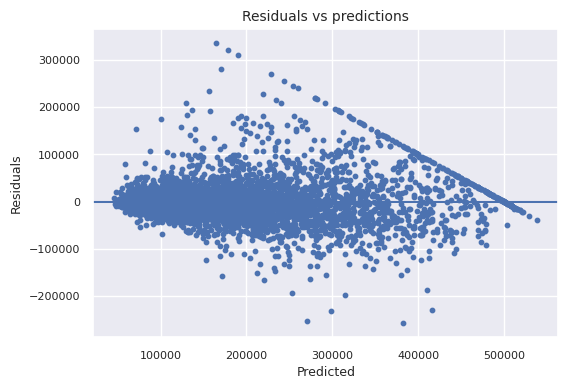

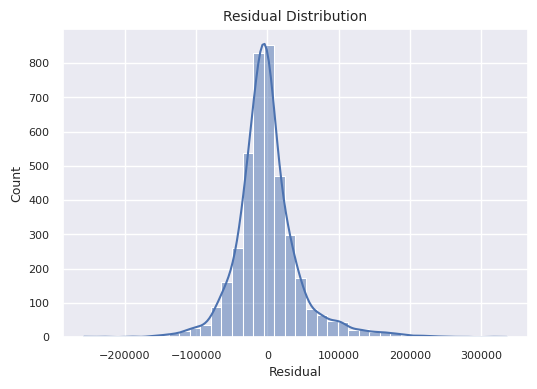

In [ ]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6,4))
plt.scatter(test_final_pred, residuals, s = 10 )
plt.axhline(0)
plt.title("Residuals vs predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [ ]:
import pandas as pd

def predict_house_price(
    model,
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:

    # Create input row as DataFrame
    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity
    }])

    # Predict and return result
    return float(model.predict(new_row)[0])

In [ ]:
# example inference
example_pred = predict_house_price(
    model=hgb_best,
    longitude=-122.230,
    latitude =37.880,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
)

print("\nExample prediction",round(example_pred,2))

print(f"Predicted house price: {example_pred:.2f}")



Example prediction 460630.17
Predicted house price: 460630.17
